✅ 2-Qubit Dense Circuit built with 12 trainable parameters.


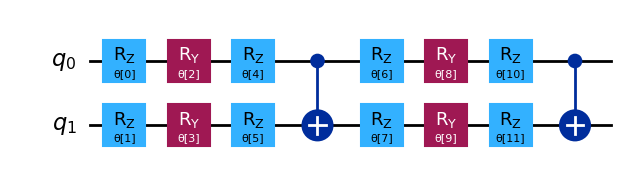

In [29]:
import numpy as np
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

# ==========================================
# 1. LOAD THE IRIS DATA (Classification)
# ==========================================
iris = load_iris()
X_all = iris.data   # 4 features
y_all = iris.target # 3 classes (0, 1, 2)

# Scale the 4 features to [-π, π]
scaler_X = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_scaled = scaler_X.fit_transform(X_all)

# Train/Test Split (120 train, 30 test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_all, test_size=30, random_state=42
)

# ==========================================
# 2. BUILD THE 2-QUBIT DENSE CIRCUIT
# ==========================================
n_qubits = 2
num_features = 4
num_layers = 2  
total_q_params = n_qubits * 3 * num_layers # 12 parameters

x_params = ParameterVector('x', num_features)
theta_params = ParameterVector('θ', total_q_params)

# --- DENSE FEATURE MAP (2 Features per Qubit) ---
feature_map = QuantumCircuit(n_qubits)
feature_map.rx(x_params[0], 0)
feature_map.ry(x_params[1], 0)
feature_map.rx(x_params[2], 1)
feature_map.ry(x_params[3], 1)

# --- DEEP ANSATZ (2 Layers) ---
ansatz = QuantumCircuit(n_qubits)
for layer in range(num_layers):
    offset = layer * (n_qubits * 3) 
    
    for i in range(n_qubits):
        ansatz.rz(theta_params[offset + i], i)
        ansatz.ry(theta_params[offset + n_qubits + i], i)
        ansatz.rz(theta_params[offset + (2*n_qubits) + i], i)
        
    # Simple Entanglement for 2 Qubits
    ansatz.cx(0, 1)

full_circuit = feature_map.compose(ansatz)
print(f"✅ 2-Qubit Dense Circuit built with {total_q_params} trainable parameters.")

# Quantum Engine Setup
observables = [SparsePauliOp.from_sparse_list([("Z", [i], 1)], num_qubits=n_qubits) for i in range(n_qubits)]
estimator = StatevectorEstimator()

def get_quantum_embedding(x_data, theta_weights):
    params = list(x_data) + list(theta_weights)
    pub = (full_circuit, observables, params)
    job = estimator.run([pub])
    return np.array(job.result()[0].data.evs)

def get_quantum_gradients(x_data, theta_weights):
    shift = np.pi / 2
    num_weights = len(theta_weights) 
    jacobian = np.zeros((n_qubits, num_weights)) # 2x12 matrix
    
    for i in range(num_weights):
        theta_plus = theta_weights.copy()
        theta_plus[i] += shift
        emb_plus = get_quantum_embedding(x_data, theta_plus)
        
        theta_minus = theta_weights.copy()
        theta_minus[i] -= shift
        emb_minus = get_quantum_embedding(x_data, theta_minus)
        
        jacobian[:, i] = 0.5 * (emb_plus - emb_minus)
        
    return jacobian
ansatz.draw('mpl')

In [32]:
# ==========================================
# 3. TRAINING THE 2-QUBIT CLASSIFIER
# ==========================================
np.random.seed(42)

# 12 Quantum Weights
theta_weights = np.random.uniform(-np.pi, np.pi, total_q_params)  

# Classical Head: 3 classes, 2 inputs from the quantum circuit
c_weights = np.random.randn(3, n_qubits) # 3x2 matrix (6 params)
c_bias = np.random.randn(3)              # 3 biases

def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z)

learning_rate = 0.1
epochs = 12  # We can run 10 easily because it's so fast!
total_train_samples = len(X_train) 

print("\n" + "=" * 50)
print(f"🌸 STARTING 2-QUBIT IRIS CLASSIFICATION")
print("Total Parameters: 21 (12 Quantum + 9 Classical)")
print("=" * 50)

start_time = time.time()

for epoch in range(epochs):
    total_loss = 0
    correct_predictions = 0
    
    for i in range(total_train_samples): 
        x_data = X_train[i] 
        true_class = y_train[i]
        
        # --- FORWARD PASS ---
        embedding = get_quantum_embedding(x_data, theta_weights)
        logits = np.dot(c_weights, embedding) + c_bias
        probabilities = softmax(logits)
        
        # Cross-Entropy Loss
        total_loss += -np.log(probabilities[true_class] + 1e-9)
        if np.argmax(probabilities) == true_class:
            correct_predictions += 1
            
        # --- BACKWARD PASS ---
        d_logits = probabilities.copy()
        d_logits[true_class] -= 1  
        
        d_c_weights = np.outer(d_logits, embedding)
        d_c_bias = d_logits
        d_embedding = np.dot(c_weights.T, d_logits)
        
        # Quantum Gradients (Only 12 parameters to shift!)
        jacobian = get_quantum_gradients(x_data, theta_weights)
        d_theta = np.dot(d_embedding, jacobian)
        
        # --- UPDATE WEIGHTS ---
        c_weights -= learning_rate * d_c_weights
        c_bias -= learning_rate * d_c_bias
        theta_weights -= learning_rate * d_theta

    avg_loss = total_loss / total_train_samples
    accuracy = (correct_predictions / total_train_samples) * 100
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {accuracy:.1f}%")

end_time = time.time()
print(f"\n✅ Training Complete! Time: {(end_time - start_time):.2f} seconds.")

# ==========================================
# 4. FINAL EVALUATION ON UNSEEN DATA
# ==========================================
correct_test = 0

for i in range(len(X_test)):
    x_data = X_test[i]
    true_class = y_test[i]
    
    embedding = get_quantum_embedding(x_data, theta_weights)
    logits = np.dot(c_weights, embedding) + c_bias
    probabilities = softmax(logits)
    
    if np.argmax(probabilities) == true_class:
        correct_test += 1

test_accuracy = (correct_test / len(X_test)) * 100
print("-" * 50)
print(f"🏆 Final Test Accuracy: {test_accuracy:.1f}%")
print("-" * 50)


🌸 STARTING 2-QUBIT IRIS CLASSIFICATION
Total Parameters: 21 (12 Quantum + 9 Classical)
Epoch  1/12 | Loss: 0.6589 | Train Acc: 74.2%
Epoch  2/12 | Loss: 0.5491 | Train Acc: 77.5%
Epoch  3/12 | Loss: 0.5013 | Train Acc: 79.2%
Epoch  4/12 | Loss: 0.4485 | Train Acc: 83.3%
Epoch  5/12 | Loss: 0.4041 | Train Acc: 82.5%
Epoch  6/12 | Loss: 0.3818 | Train Acc: 85.0%
Epoch  7/12 | Loss: 0.3705 | Train Acc: 85.0%
Epoch  8/12 | Loss: 0.3621 | Train Acc: 85.0%
Epoch  9/12 | Loss: 0.3528 | Train Acc: 85.0%
Epoch 10/12 | Loss: 0.3425 | Train Acc: 86.7%
Epoch 11/12 | Loss: 0.3373 | Train Acc: 84.2%
Epoch 12/12 | Loss: 0.3324 | Train Acc: 85.0%

✅ Training Complete! Time: 213.12 seconds.
--------------------------------------------------
🏆 Final Test Accuracy: 83.3%
--------------------------------------------------


In [10]:
# --- UPDATED STEP 4 FOR QISKIT 1.0+ ---
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# 1. Snap your Step 2 (Encoding) and Step 3 (Ansatz) circuits together!
full_circuit = feature_map.compose(ansatz)

# 2. Define our "Meters" (Pauli-Z Observables)
# We want to measure the Z-axis for qubit 0, 1, 2, and 3.
observables = [SparsePauliOp.from_sparse_list([("Z", [i], 1)], num_qubits=n_qubits) for i in range(n_qubits)]

# 3. Create the new V2 Estimator
estimator = StatevectorEstimator()

def get_quantum_embedding(x_data, theta_weights):
    """Runs the circuit and returns 4 classical numbers."""
    # Combine the 4 data angles and 24 weight angles into one list
    params = list(x_data) + list(theta_weights)
    
    # In Qiskit 1.0+, we pack everything into a single "PUB" 
    # Format: (Circuit, List of Observables, Parameters)
    pub = (full_circuit, observables, params)
    
    # Run the estimator
    job = estimator.run([pub])
    
    # Extract the expectation values (evs) from the result
    return np.array(job.result()[0].data.evs)

print("Step 4 Complete! V2 Estimator initialized.")

Step 4 Complete! V2 Estimator initialized.


In [14]:
import numpy as np

# ==========================================
# STEP 5: The Classical Network
# ==========================================
def classical_network(embedding, c_weights, c_biases):
    """
    Takes the 4 numbers from the quantum circuit, multiplies them by classical weights,
    and outputs 3 probabilities (one for each Iris flower type).
    """
    # Linear layer: y = W*x + b
    logits = np.dot(c_weights, embedding) + c_biases
    
    # Softmax: convert raw numbers into probabilities (0.0 to 1.0)
    exp_logits = np.exp(logits - np.max(logits)) # The max() is just for numerical stability
    probabilities = exp_logits / np.sum(exp_logits)
    
    return probabilities

# ==========================================
# STEP 6a: The Parameter-Shift Rule (Quantum Gradients)
# ==========================================
def get_quantum_gradients(x_data, theta_weights):
    """Calculates exactly how tweaking the 24 quantum angles changes the 4 output numbers."""
    shift = np.pi / 2
    jacobian = np.zeros((4, 24)) 
    
    for i in range(24):
        # Shift parameter UP by pi/2 and measure
        theta_plus = theta_weights.copy()
        theta_plus[i] += shift
        emb_plus = get_quantum_embedding(x_data, theta_plus)
        
        # Shift parameter DOWN by pi/2 and measure
        theta_minus = theta_weights.copy()
        theta_minus[i] -= shift
        emb_minus = get_quantum_embedding(x_data, theta_minus)
        
        # Calculate exact analytical gradient
        jacobian[:, i] = 0.5 * (emb_plus - emb_minus)
        
    return jacobian

# ==========================================
# STEP 6b: The Training Loop
# ==========================================
print("Initializing Weights...")
np.random.seed(42)
theta_weights = np.random.uniform(-np.pi, np.pi, 24)  # 24 Quantum angles
c_weights = np.random.randn(3, 4)                     # 3 classes, 4D embedding
c_biases = np.random.randn(3)

learning_rate = 0.05
epochs = 10      # Just 3 loops to test it out
batch_size = 30   # Just 5 flowers to keep the test run fast

print("Starting Manual Hybrid Training...")
for epoch in range(epochs):
    total_loss = 0
    
    for i in range(batch_size): 
        x_data = X_train[i]
        true_label = y_train[i]
        
        # --- 1. FORWARD PASS ---
        # Get 4 numbers from quantum circuit
        embedding = get_quantum_embedding(x_data, theta_weights)
        # Get 3 probabilities from classical network
        probs = classical_network(embedding, c_weights, c_biases)
        
        # Calculate Cross-Entropy Loss
        total_loss += -np.log(probs[true_label] + 1e-9)
        
        # --- 2. BACKWARD PASS (The Chain Rule) ---
        d_logits = probs.copy()
        d_logits[true_label] -= 1  
        
        # Classical Gradients
        d_c_weights = np.outer(d_logits, embedding)
        d_c_biases = d_logits
        
        # How much the classical network blames the quantum embedding:
        d_embedding = np.dot(c_weights.T, d_logits)
        
        # Get Quantum Gradients via our Shift function
        jacobian = get_quantum_gradients(x_data, theta_weights)
        
        # Chain Rule! Multiply classical blame by quantum gradients
        d_theta = np.dot(d_embedding, jacobian)
        
        # --- 3. UPDATE WEIGHTS ---
        c_weights -= learning_rate * d_c_weights
        c_biases -= learning_rate * d_c_biases
        theta_weights -= learning_rate * d_theta

    print(f"Epoch {epoch+1}/{epochs} | Average Loss: {total_loss/batch_size:.4f}")

print("\nTraining complete! Your hybrid model is learning.")

Initializing Weights...
Starting Manual Hybrid Training...
Epoch 1/10 | Average Loss: 1.1187
Epoch 2/10 | Average Loss: 0.7811
Epoch 3/10 | Average Loss: 0.6280
Epoch 4/10 | Average Loss: 0.5421
Epoch 5/10 | Average Loss: 0.4928
Epoch 6/10 | Average Loss: 0.4623
Epoch 7/10 | Average Loss: 0.4413
Epoch 8/10 | Average Loss: 0.4255
Epoch 9/10 | Average Loss: 0.4127
Epoch 10/10 | Average Loss: 0.4018

Training complete! Your hybrid model is learning.


In [15]:
# ==========================================
# EVALUATION: Testing the Trained Model
# ==========================================
print("Evaluating model on unseen test data...")

correct_predictions = 0
total_test_samples = len(X_test) # There are 30 flowers in our test set

# Loop through all 30 unseen test flowers
for i in range(total_test_samples):
    x_data = X_test[i]
    true_label = y_test[i]
    
    # 1. Forward Pass: Get the quantum embedding
    embedding = get_quantum_embedding(x_data, theta_weights)
    
    # 2. Forward Pass: Get the 3 classical probabilities
    probs = classical_network(embedding, c_weights, c_biases)
    
    # 3. The prediction is the class with the highest probability
    predicted_label = np.argmax(probs)
    
    # Check if the model guessed correctly
    if predicted_label == true_label:
        correct_predictions += 1

# Calculate the final percentage
accuracy = (correct_predictions / total_test_samples) * 100

print("-" * 30)
print(f"Final Test Accuracy: {accuracy:.2f}%")
print(f"Correctly predicted {correct_predictions} out of {total_test_samples} flowers.")
print

Evaluating model on unseen test data...
------------------------------
Final Test Accuracy: 96.67%
Correctly predicted 29 out of 30 flowers.


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [ ]:
import time

print("Starting FULL Hybrid Training on all 120 flowers...")
# Make sure your learning rate is set appropriately
learning_rate = 0.05
epochs = 10 
total_train_samples = len(X_train) # This is exactly 120!

start_time = time.time()

for epoch in range(epochs):
    total_loss = 0
    
    # We are now looping through EVERY flower in the training set
    for i in range(total_train_samples): 
        x_data = X_train[i]
        true_label = y_train[i]
        
        # --- FORWARD PASS ---
        embedding = get_quantum_embedding(x_data, theta_weights)
        probs = classical_network(embedding, c_weights, c_biases)
        
        # Cross-Entropy Loss
        total_loss += -np.log(probs[true_label] + 1e-9)
        
        # --- BACKWARD PASS ---
        d_logits = probs.copy()
        d_logits[true_label] -= 1  
        
        d_c_weights = np.outer(d_logits, embedding)
        d_c_biases = d_logits
        d_embedding = np.dot(c_weights.T, d_logits)
        
        # QUANTUM GRADIENTS (The heavy computation)
        jacobian = get_quantum_gradients(x_data, theta_weights)
        d_theta = np.dot(d_embedding, jacobian)
        
        # --- UPDATE WEIGHTS ---
        c_weights -= learning_rate * d_c_weights
        c_biases -= learning_rate * d_c_biases
        theta_weights -= learning_rate * d_theta
        
        # Print a tiny dot every 10 flowers so you know it's working!
        if (i + 1) % 10 == 0:
            print(".", end="", flush=True)

    # Print the stats at the end of each epoch
    avg_loss = total_loss / total_train_samples
    print(f"\nEpoch {epoch+1}/{epochs} Complete | Average Loss: {avg_loss:.4f}")

end_time = time.time()
print(f"\n🎉 Full Training Complete! It took {(end_time - start_time)/60:.2f} minutes.")

## Update extra training and entanglement layer

Deep circuit built successfully with 36 trainable parameters!


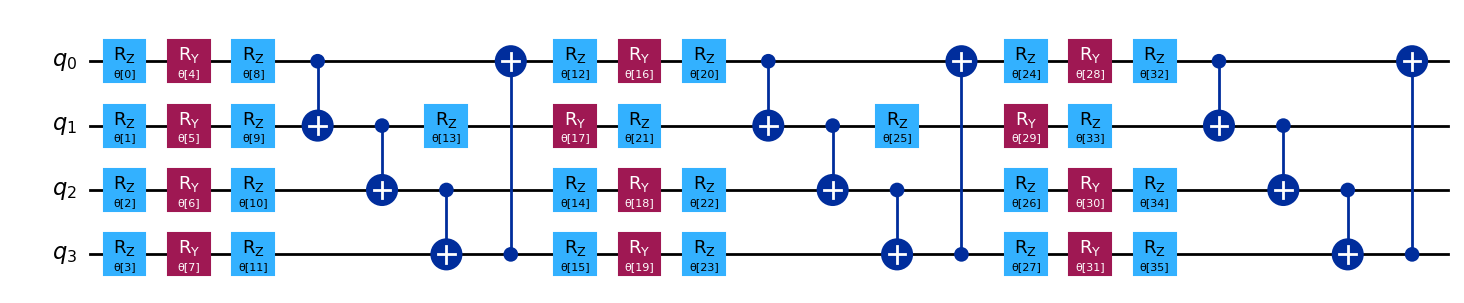

In [6]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# 1. Define the dimensions
n_qubits = 4
num_layers = 3  # We bumped this up from 2 to 3!
total_params = n_qubits * 3 * num_layers # 36 total parameters

# 2. Create our placeholders
x_params = ParameterVector('x', n_qubits)
theta_params = ParameterVector('θ', total_params)

# 3. Build the Encoder (Feature Map)
feature_map = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    feature_map.rx(x_params[i], i)

# 4. Build the Deep Ansatz (Trainable Layers)
ansatz = QuantumCircuit(n_qubits)

# Loop to dynamically build the layers
for layer in range(num_layers):
    offset = layer * (n_qubits * 3) # Jumps by 12 for each layer
    
    # Extra Training Layer (Rz, Ry, Rz)
    for i in range(n_qubits):
        ansatz.rz(theta_params[offset + i], i)
        ansatz.ry(theta_params[offset + 4 + i], i)
        ansatz.rz(theta_params[offset + 8 + i], i)
        
    # Extra Entanglement Layer (CNOT Ring)
    for i in range(n_qubits - 1):
        ansatz.cx(i, i + 1)
    ansatz.cx(n_qubits - 1, 0)

# 5. Snap them together
full_circuit = feature_map.compose(ansatz)
print(f"Deep circuit built successfully with {total_params} trainable parameters!")
ansatz.draw('mpl')



In [5]:
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

# Define our 4 Z-axis meters
observables = [SparsePauliOp.from_sparse_list([("Z", [i], 1)], num_qubits=n_qubits) for i in range(n_qubits)]
estimator = StatevectorEstimator()

def get_quantum_embedding(x_data, theta_weights):
    """Runs the circuit and returns the 4D embedding."""
    params = list(x_data) + list(theta_weights)
    pub = (full_circuit, observables, params)
    job = estimator.run([pub])
    return np.array(job.result()[0].data.evs)

def get_quantum_gradients(x_data, theta_weights):
    """Calculates the 36 quantum gradients using the Parameter-Shift Rule."""
    shift = np.pi / 2
    num_weights = len(theta_weights) # Automatically detects our 36 parameters
    jacobian = np.zeros((4, num_weights)) 
    
    # Now it loops 36 times to calculate shifts for every single weight
    for i in range(num_weights):
        theta_plus = theta_weights.copy()
        theta_plus[i] += shift
        emb_plus = get_quantum_embedding(x_data, theta_plus)
        
        theta_minus = theta_weights.copy()
        theta_minus[i] -= shift
        emb_minus = get_quantum_embedding(x_data, theta_minus)
        
        jacobian[:, i] = 0.5 * (emb_plus - emb_minus)
        
    return jacobian
    
print("Quantum Engine and Gradient functions updated!")

Quantum Engine and Gradient functions updated!


In [7]:
# 1. The Classical Softmax Network
def classical_network(embedding, c_weights, c_biases):
    logits = np.dot(c_weights, embedding) + c_biases
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / np.sum(exp_logits)

# 2. Initialize Weights
np.random.seed(42)
theta_weights = np.random.uniform(-np.pi, np.pi, total_params) # Creates 36 weights!
c_weights = np.random.randn(3, 4)                     
c_biases = np.random.randn(3)

# 3. Training Hyperparameters
learning_rate = 0.05
epochs = 5
batch_size = 30 # Training on 30 flowers

print(f"Starting Training with {total_params} quantum parameters...")

for epoch in range(epochs):
    total_loss = 0
    
    for i in range(batch_size): 
        x_data = X_train[i] 
        true_label = y_train[i]
        
        # FORWARD PASS
        embedding = get_quantum_embedding(x_data, theta_weights)
        probs = classical_network(embedding, c_weights, c_biases) 
        total_loss += -np.log(probs[true_label] + 1e-9)
        
        # BACKWARD PASS
        d_logits = probs.copy()
        d_logits[true_label] -= 1  
        
        d_c_weights = np.outer(d_logits, embedding)
        d_c_biases = d_logits
        d_embedding = np.dot(c_weights.T, d_logits)
        
        # QUANTUM GRADIENTS (72 circuit runs per flower!)
        jacobian = get_quantum_gradients(x_data, theta_weights)
        d_theta = np.dot(d_embedding, jacobian)
        
        # UPDATE WEIGHTS
        c_weights -= learning_rate * d_c_weights
        c_biases -= learning_rate * d_c_biases
        theta_weights -= learning_rate * d_theta

    print(f"Epoch {epoch+1}/{epochs} | Average Loss: {total_loss/batch_size:.4f}")

Starting Training with 36 quantum parameters...
Epoch 1/5 | Average Loss: 0.7650
Epoch 2/5 | Average Loss: 0.5635
Epoch 3/5 | Average Loss: 0.4851
Epoch 4/5 | Average Loss: 0.4362
Epoch 5/5 | Average Loss: 0.3999


In [8]:
# ==========================================
# Part 4: EVALUATION (Testing the Deep Model)
# ==========================================
print("Evaluating deep model on unseen test data...")

correct_predictions = 0
total_test_samples = len(X_test) # There are 30 flowers in our test set

# Loop through all 30 unseen test flowers
for i in range(total_test_samples):
    x_data = X_test[i]
    true_label = y_test[i]
    
    # 1. Forward Pass: Get the quantum embedding using our deep 36-weight circuit
    embedding = get_quantum_embedding(x_data, theta_weights)
    
    # 2. Forward Pass: Get the 3 classical probabilities
    probs = classical_network(embedding, c_weights, c_biases)
    
    # 3. The prediction is the class with the highest probability
    predicted_label = np.argmax(probs)
    
    # Check if the model guessed correctly
    if predicted_label == true_label:
        correct_predictions += 1

# Calculate the final percentage
accuracy = (correct_predictions / total_test_samples) * 100

print("-" * 30)
print(f"Final Test Accuracy: {accuracy:.2f}%")
print(f"Correctly predicted {correct_predictions} out of {total_test_samples} flowers.")
print("-" * 30)

Evaluating deep model on unseen test data...
------------------------------
Final Test Accuracy: 93.33%
Correctly predicted 28 out of 30 flowers.
------------------------------


In [9]:
import time
import numpy as np

# ==========================================
# 1. INITIALIZATION
# ==========================================
print(f"Initializing {total_params} Quantum Weights for {num_layers} layers...")
np.random.seed(42)

# 36 quantum weights, 12 classical weights, 3 classical biases
theta_weights = np.random.uniform(-np.pi, np.pi, total_params)  
c_weights = np.random.randn(3, 4)                     
c_biases = np.random.randn(3)

learning_rate = 0.05
epochs = 5
total_train_samples = len(X_train) # Using ALL 120 flowers!

# Lists to save our progress for plotting later
loss_history = []

# ==========================================
# 2. FULL TRAINING LOOP
# ==========================================
print("-" * 40)
print(f"Starting FULL Deep Hybrid Training...")
print(f"Executing {total_train_samples * len(theta_weights) * 2} quantum circuits per epoch.")
print("-" * 40)

start_time = time.time()

for epoch in range(epochs):
    total_loss = 0
    
    # Loop through EVERY flower in the training set
    for i in range(total_train_samples): 
        x_data = X_train[i] 
        true_label = y_train[i]
        
        # --- FORWARD PASS ---
        embedding = get_quantum_embedding(x_data, theta_weights)
        probs = classical_network(embedding, c_weights, c_biases) 
        
        # --- LOSS ---
        total_loss += -np.log(probs[true_label] + 1e-9)
        
        # --- BACKWARD PASS ---
        d_logits = probs.copy()
        d_logits[true_label] -= 1  
        
        d_c_weights = np.outer(d_logits, embedding)
        d_c_biases = d_logits
        d_embedding = np.dot(c_weights.T, d_logits)
        
        # Calculate gradients for all 36 weights
        jacobian = get_quantum_gradients(x_data, theta_weights)
        d_theta = np.dot(d_embedding, jacobian)
        
        # --- UPDATE WEIGHTS ---
        c_weights -= learning_rate * d_c_weights
        c_biases -= learning_rate * d_c_biases
        theta_weights -= learning_rate * d_theta
        
        # Progress tracker: Print a dot every 10 flowers
        if (i + 1) % 10 == 0:
            print(".", end="", flush=True)

    # Save and print epoch stats
    avg_loss = total_loss / total_train_samples
    loss_history.append(avg_loss)
    print(f" | Epoch {epoch+1}/{epochs} Complete | Avg Loss: {avg_loss:.4f}")

end_time = time.time()
print(f"\n🎉 Full Training Complete! It took {(end_time - start_time)/60:.2f} minutes.")

# ==========================================
# 3. FINAL EVALUATION ON TEST SET
# ==========================================
print("\n" + "=" * 40)
print("EVALUATING ON UNSEEN TEST DATA")
print("=" * 40)

correct_predictions = 0
total_test_samples = len(X_test) # All 30 test flowers

for i in range(total_test_samples):
    x_data = X_test[i]
    true_label = y_test[i]
    
    embedding = get_quantum_embedding(x_data, theta_weights)
    probs = classical_network(embedding, c_weights, c_biases)
    predicted_label = np.argmax(probs)
    
    if predicted_label == true_label:
        correct_predictions += 1

accuracy = (correct_predictions / total_test_samples) * 100

print(f"Final Test Accuracy: {accuracy:.2f}%")
print(f"Correctly predicted {correct_predictions} out of {total_test_samples} flowers.")
print("-" * 40)


Initializing 36 Quantum Weights for 3 layers...
----------------------------------------
Starting FULL Deep Hybrid Training...
Executing 8640 quantum circuits per epoch.
----------------------------------------
............ | Epoch 1/5 Complete | Avg Loss: 0.6179
............ | Epoch 2/5 Complete | Avg Loss: 0.4182
............ | Epoch 3/5 Complete | Avg Loss: 0.3444
............ | Epoch 4/5 Complete | Avg Loss: 0.2986
............ | Epoch 5/5 Complete | Avg Loss: 0.2674

🎉 Full Training Complete! It took 10.27 minutes.

EVALUATING ON UNSEEN TEST DATA
Final Test Accuracy: 93.33%
Correctly predicted 28 out of 30 flowers.
----------------------------------------


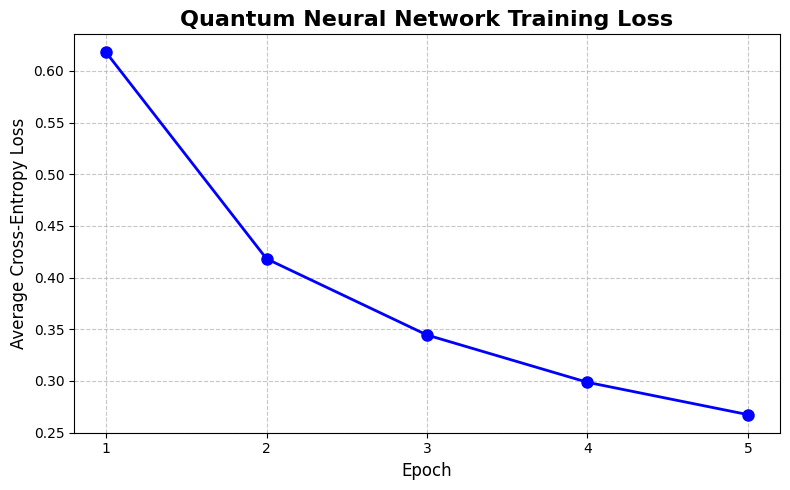

In [10]:
import matplotlib.pyplot as plt

# ==========================================
# VISUALIZE THE TRAINING PROGRESS
# ==========================================
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss_history, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Add titles and labels
plt.title('Quantum Neural Network Training Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Cross-Entropy Loss', fontsize=12)

# Make it look clean
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

In [11]:
import time
import numpy as np

# ==========================================
# EXPERIMENT SETUP
# ==========================================
training_sizes = [40, 80, 120]
epochs = 10
learning_rate = 0.05

# We will store the loss history and final accuracy for each run here
experiment_results = {
    'losses': {},
    'accuracies': {}
}

total_start_time = time.time()

for size in training_sizes:
    print("\n" + "=" * 50)
    print(f"🚀 STARTING RUN: Training on {size} flowers")
    print("=" * 50)
    
    # 1. Reset Weights for a fair experiment!
    np.random.seed(42)
    theta_weights = np.random.uniform(-np.pi, np.pi, total_params)  
    c_weights = np.random.randn(3, 4)                     
    c_biases = np.random.randn(3)
    
    # 2. Subset the training data
    X_subset = X_train[:size]
    y_subset = y_train[:size]
    
    loss_history = []
    
    # 3. Training Loop
    for epoch in range(epochs):
        total_loss = 0
        
        for i in range(size): 
            x_data = X_subset[i] 
            true_label = y_subset[i]
            
            # Forward Pass
            embedding = get_quantum_embedding(x_data, theta_weights)
            probs = classical_network(embedding, c_weights, c_biases) 
            
            # Loss
            total_loss += -np.log(probs[true_label] + 1e-9)
            
            # Backward Pass
            d_logits = probs.copy()
            d_logits[true_label] -= 1  
            
            d_c_weights = np.outer(d_logits, embedding)
            d_c_biases = d_logits
            d_embedding = np.dot(c_weights.T, d_logits)
            
            # Quantum Gradients
            jacobian = get_quantum_gradients(x_data, theta_weights)
            d_theta = np.dot(d_embedding, jacobian)
            
            # Update Weights
            c_weights -= learning_rate * d_c_weights
            c_biases -= learning_rate * d_c_biases
            theta_weights -= learning_rate * d_theta
            
            if (i + 1) % 20 == 0:
                print(".", end="", flush=True)

        avg_loss = total_loss / size
        loss_history.append(avg_loss)
        print(f" | Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.4f}")
        
    experiment_results['losses'][size] = loss_history
    
    # 4. Evaluation on the fixed Test Set (30 flowers)
    correct_predictions = 0
    total_test_samples = len(X_test)

    for i in range(total_test_samples):
        x_data = X_test[i]
        true_label = y_test[i]
        
        embedding = get_quantum_embedding(x_data, theta_weights)
        probs = classical_network(embedding, c_weights, c_biases)
        predicted_label = np.argmax(probs)
        
        if predicted_label == true_label:
            correct_predictions += 1

    accuracy = (correct_predictions / total_test_samples) * 100
    experiment_results['accuracies'][size] = accuracy
    
    print(f"🎯 Final Accuracy for {size} training samples: {accuracy:.2f}%")

total_end_time = time.time()
print("\n" + "*" * 50)
print(f"✅ ALL EXPERIMENTS COMPLETE! Total time: {(total_end_time - total_start_time)/60:.2f} minutes.")
print("*" * 50)


🚀 STARTING RUN: Training on 40 flowers
.. | Epoch 1/10 | Avg Loss: 0.7107
.. | Epoch 2/10 | Avg Loss: 0.5159
.. | Epoch 3/10 | Avg Loss: 0.4412
.. | Epoch 4/10 | Avg Loss: 0.3941
.. | Epoch 5/10 | Avg Loss: 0.3594
.. | Epoch 6/10 | Avg Loss: 0.3310
.. | Epoch 7/10 | Avg Loss: 0.3065
.. | Epoch 8/10 | Avg Loss: 0.2848
.. | Epoch 9/10 | Avg Loss: 0.2655
.. | Epoch 10/10 | Avg Loss: 0.2486
🎯 Final Accuracy for 40 training samples: 93.33%

🚀 STARTING RUN: Training on 80 flowers
.... | Epoch 1/10 | Avg Loss: 0.6610
.... | Epoch 2/10 | Avg Loss: 0.4604
.... | Epoch 3/10 | Avg Loss: 0.3845
.... | Epoch 4/10 | Avg Loss: 0.3360
.... | Epoch 5/10 | Avg Loss: 0.3007
.... | Epoch 6/10 | Avg Loss: 0.2748
.... | Epoch 7/10 | Avg Loss: 0.2565
.... | Epoch 8/10 | Avg Loss: 0.2433
.... | Epoch 9/10 | Avg Loss: 0.2332
.... | Epoch 10/10 | Avg Loss: 0.2248
🎯 Final Accuracy for 80 training samples: 96.67%

🚀 STARTING RUN: Training on 120 flowers
...... | Epoch 1/10 | Avg Loss: 0.6179
...... | Epoch 2/10 

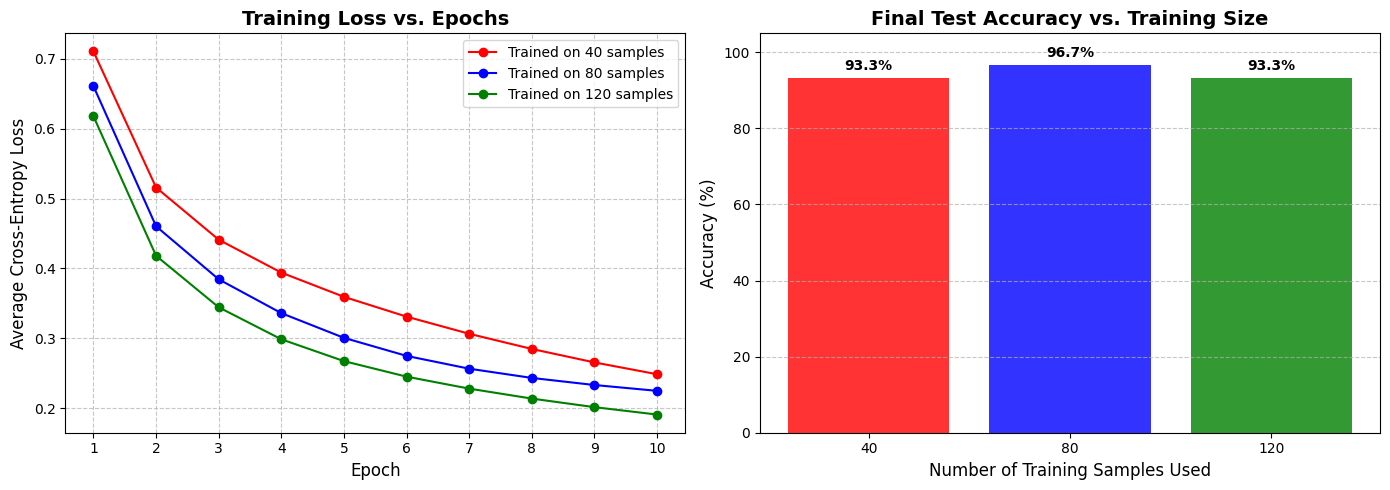

In [12]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: The Loss Curves ---
epochs_range = range(1, epochs + 1)
colors = ['red', 'blue', 'green']

for idx, size in enumerate(training_sizes):
    ax1.plot(epochs_range, experiment_results['losses'][size], 
             marker='o', color=colors[idx], label=f'Trained on {size} samples')

ax1.set_title('Training Loss vs. Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Average Cross-Entropy Loss', fontsize=12)
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# --- Plot 2: The Final Accuracies ---
sizes_str = [str(size) for size in training_sizes]
accuracies = [experiment_results['accuracies'][size] for size in training_sizes]

bars = ax2.bar(sizes_str, accuracies, color=colors, alpha=0.8)
ax2.set_title('Final Test Accuracy vs. Training Size', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Training Samples Used', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_ylim(0, 105)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add the percentage text on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==========================================
# RANDOM FOREST EXPERIMENT
# ==========================================
training_sizes = [40, 80, 120]

# Dictionary to store our classical results
rf_results = {
    'accuracies': {},
    'times': {}
}

print("=" * 50)
print("🌲 STARTING CLASSICAL RANDOM FOREST BASELINE")
print("=" * 50)

for size in training_sizes:
    # 1. Subset the training data
    X_subset = X_train[:size]
    y_subset = y_train[:size]
    
    # 2. Initialize the Random Forest (using 100 trees)
    rf_model = RandomForestClassifier(n_estimators=1, random_state=42)
    
    # 3. Train the model and time it
    start_time = time.time()
    rf_model.fit(X_subset, y_subset) # No epochs, just one 'fit' command!
    end_time = time.time()
    
    # 4. Evaluate on the fixed Test Set (30 flowers)
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    
    # 5. Save results
    training_time = end_time - start_time
    rf_results['accuracies'][size] = accuracy
    rf_results['times'][size] = training_time
    
    print(f"Trained on {size:3} samples | Accuracy: {accuracy:.2f}% | Time: {training_time:.4f} seconds")

print("\n✅ Classical Baseline Complete!")

🌲 STARTING CLASSICAL RANDOM FOREST BASELINE
Trained on  40 samples | Accuracy: 100.00% | Time: 0.0022 seconds
Trained on  80 samples | Accuracy: 93.33% | Time: 0.0015 seconds
Trained on 120 samples | Accuracy: 100.00% | Time: 0.0011 seconds

✅ Classical Baseline Complete!


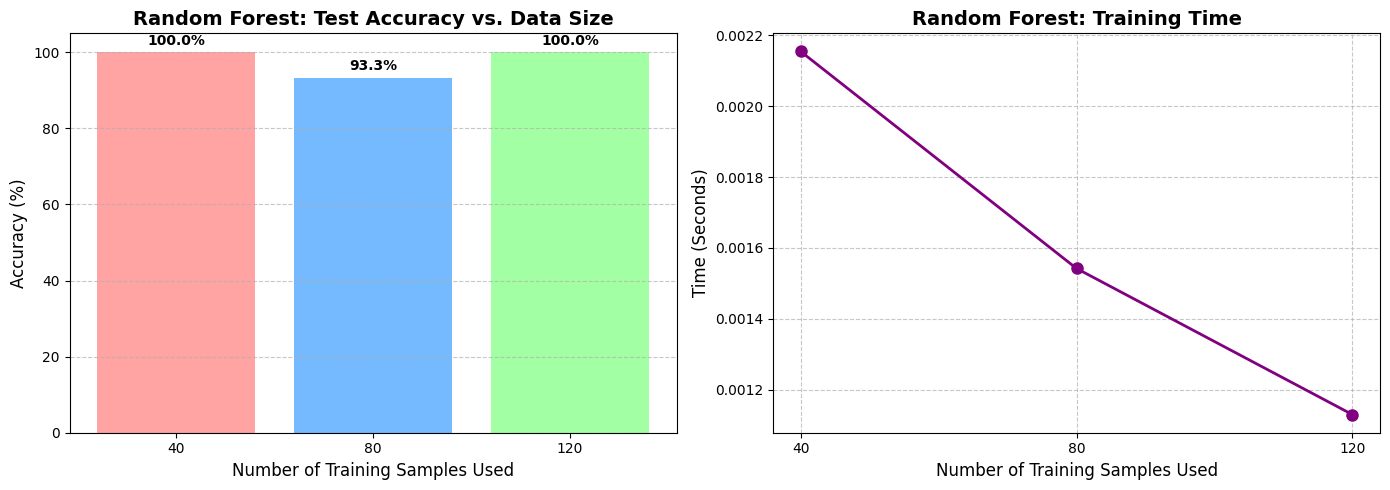

In [25]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF9999', '#66B2FF', '#99FF99'] # Different colors to distinguish from Quantum

sizes_str = [str(size) for size in training_sizes]
rf_accuracies = [rf_results['accuracies'][size] for size in training_sizes]
rf_times = [rf_results['times'][size] for size in training_sizes]

# --- Plot 1: The Final Accuracies (Bar Chart) ---
bars = ax1.bar(sizes_str, rf_accuracies, color=colors, alpha=0.9)
ax1.set_title('Random Forest: Test Accuracy vs. Data Size', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Training Samples Used', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_ylim(0, 105)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add the percentage text on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}%', ha='center', fontweight='bold')

# --- Plot 2: Training Time (Line Chart) ---
ax2.plot(sizes_str, rf_times, marker='o', color='purple', linewidth=2, markersize=8)
ax2.set_title('Random Forest: Training Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Training Samples Used', fontsize=12)
ax2.set_ylabel('Time (Seconds)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [3]:
import time
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import SPSA, COBYLA, L_BFGS_B
from qiskit_machine_learning.algorithms.classifiers import VQC

# ==========================================
# 1. Classical Data Preparation (All 3 Classes)
# ==========================================
print("Loading Iris data (All 3 Classes)...")
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# Scale features to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# One-Hot Encode the labels for multi-class VQC
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# ==========================================
# 2. Quantum Circuit Setup
# ==========================================
num_features = X.shape[1]
feature_map = ZZFeatureMap(feature_dimension=num_features, reps=1)
ansatz = RealAmplitudes(num_qubits=num_features, reps=1)

# ==========================================
# 3. Experiment Runner Function
# ==========================================
def run_experiment(train_size, test_size, optimizer, opt_name):
    # Split the data based on requested sizes
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_onehot, train_size=train_size, test_size=test_size, random_state=42
    )
    
    # Initialize VQC with the specific optimizer
    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
    )
    
    print(f"Training with {opt_name} on {train_size}-{test_size} split...")
    
    # Track time and train
    start_time = time.time()
    vqc.fit(X_train, y_train)
    end_time = time.time()
    
    # Evaluate
    train_acc = vqc.score(X_train, y_train)
    test_acc = vqc.score(X_test, y_test)
    train_time = end_time - start_time
    
    return {
        "Optimizer": opt_name,
        "Split": f"{train_size}-{test_size}",
        "Train Acc": round(train_acc, 3),
        "Test Acc": round(test_acc, 3),
        "Time (s)": round(train_time, 2)
    }

# ==========================================
# 4. Define Optimizers (Fixed at 40 iterations for fair time comparison)
# ==========================================
max_iters = 40
optimizers = [
    (L_BFGS_B(maxiter=max_iters), "Param Shift (L-BFGS-B)"),
    (SPSA(maxiter=max_iters), "SPSA"),
    (COBYLA(maxiter=max_iters), "COBYLA")
]

splits = [
    (100, 50),
    (120, 30)
]

# ==========================================
# 5. Run the Benchmarks
# ==========================================
results = []

for train_s, test_s in splits:
    print(f"\n--- Starting Split: {train_s} Train / {test_s} Test ---")
    for opt, name in optimizers:
        res = run_experiment(train_s, test_s, opt, name)
        results.append(res)

# Display Results as a DataFrame
df_results = pd.DataFrame(results)
print("\n=== FINAL COMPARISON RESULTS ===")
print(df_results.to_string(index=False))

/tmp/ipykernel_7120/1850969185.py:32: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_features, reps=1)
/tmp/ipykernel_7120/1850969185.py:33: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_features, reps=1)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Loading Iris data (All 3 Classes)...

--- Starting Split: 100 Train / 50 Test ---
Training with Param Shift (L-BFGS-B) on 100-50 split...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Training with SPSA on 100-50 split...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


...


--- Starting Split: 120 Train / 30 Test ---
Training with Param Shift (L-BFGS-B) on 120-30 split...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Training with SPSA on 120-30 split...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Training with COBYLA on 120-30 split...

=== FINAL COMPARISON RESULTS ===
             Optimizer  Split  Train Acc  Test Acc  Time (s)
Param Shift (L-BFGS-B) 100-50      0.540     0.560    174.37
                  SPSA 100-50      0.500     0.520     39.06
                COBYLA 100-50      0.440     0.420     11.97
Param Shift (L-BFGS-B) 120-30      0.567     0.533    187.62
                  SPSA 120-30      0.567     0.533     48.23
                COBYLA 120-30      0.558     0.500     14.82


In [2]:
!pip install qiskit_algorithms qiskit_machine_learning scikit-learn matplotlib pandas

  Using cached qiskit_machine_learning-0.9.0-py3-none-any.whl.metadata (13 kB)
Using cached qiskit_machine_learning-0.9.0-py3-none-any.whl (263 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 5.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [qiskit_algorithms]qiskit_algorithms]rning]
